# 04 — Eigenvalues & Eigenvectors

This notebook implements eigen-decomposition from scratch
(`src/eigen.py`) using the QR algorithm, and a simpler power-iteration
method for finding just the dominant eigenvector. Both are checked
against `numpy.linalg.eigh`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
np.set_printoptions(precision=4, suppress=True)

import matplotlib.pyplot as plt

## The eigenvalue equation

For a square matrix $A$, a vector $v \neq 0$ is an **eigenvector** with
**eigenvalue** $\lambda$ if:

$$Av = \lambda v$$

In words: applying $A$ to $v$ only scales $v$, without changing its
direction.

In [2]:
A = np.array([[4, 1],
              [1, 3]], dtype=float)
A

array([[4., 1.],
       [1., 3.]])

## Eigen-decomposition via the QR algorithm (from scratch)

In [3]:
from eigen import eigen_decomposition

eigenvalues, eigenvectors = eigen_decomposition(A)
print("Eigenvalues (mine):", eigenvalues)
print("Eigenvectors (mine):\n", eigenvectors)

Eigenvalues (mine): [4.618 2.382]
Eigenvectors (mine):
 [[ 0.8507 -0.5257]
 [ 0.5257  0.8507]]


In [4]:
np_eigenvalues, np_eigenvectors = np.linalg.eigh(A)
# numpy.linalg.eigh returns ascending order; reverse to match descending order above
print("Eigenvalues (numpy):", np_eigenvalues[::-1])
print("Eigenvectors (numpy):\n", np_eigenvectors[:, ::-1])

Eigenvalues (numpy): [4.618 2.382]
Eigenvectors (numpy):
 [[-0.8507  0.5257]
 [-0.5257 -0.8507]]


## Verifying $Av = \lambda v$ for each eigenpair

In [5]:
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    print(f"A @ v{i+1}       =", A @ v)
    print(f"lambda{i+1} * v{i+1} =", lam * v)
    print()

A @ v1       = [3.9283 2.4278]
lambda1 * v1 = [3.9283 2.4278]

A @ v2       = [-1.2523  2.0262]
lambda2 * v2 = [-1.2523  2.0262]



## Power iteration (finds the dominant eigenpair only)

A simpler, more intuitive method: repeatedly apply $A$ to a random vector
and renormalize. The vector converges to the eigenvector with the
largest-magnitude eigenvalue.

In [6]:
from eigen import power_iteration

dom_value, dom_vector = power_iteration(A)
print("Dominant eigenvalue (power iteration):", dom_value)
print("Dominant eigenvector (power iteration):", dom_vector)
print("Compare to QR algorithm's top eigenpair:", eigenvalues[0], eigenvectors[:, 0])

Dominant eigenvalue (power iteration): 4.618033988738581
Dominant eigenvector (power iteration): [0.8507 0.5257]
Compare to QR algorithm's top eigenpair: 4.618033988749894 [0.8507 0.5257]


## Visualizing eigenvectors

The eigenvectors of $A$ point along the axes that the matrix stretches
without rotating — shown here scaled by their eigenvalues.

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_653/2899908382.py:6: SyntaxWarning: invalid escape sequence '\l'
  label=f"$\lambda_{i+1}$={eigenvalues[i]:.2f}")


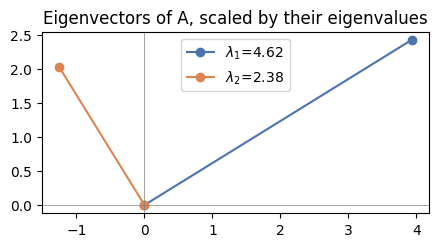

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
colors = ["#4C72B0", "#DD8452"]
for i in range(2):
    v = eigenvectors[:, i] * eigenvalues[i]
    ax.plot([0, v[0]], [0, v[1]], "-o", color=colors[i],
            label=f"$\lambda_{i+1}$={eigenvalues[i]:.2f}")

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Eigenvectors of A, scaled by their eigenvalues")
plt.show()

## Why this matters for ML

Eigen-decomposition of a covariance matrix is exactly what **PCA** uses to
find the directions of maximum variance in a dataset — the eigenvector
with the largest eigenvalue points along the direction the data spreads
out the most. That's the final notebook, next.